In [1]:
import os
import tensorflow as tf
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras
import glob
import os
import re
from tensorflow.keras import layers, models


2025-11-13 05:04:33.954067: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-13 05:04:33.954138: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-13 05:04:33.955924: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-13 05:04:33.964612: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-13 05:04:34.922792: W tensorflow/compiler/tf2

In [2]:
threshold_offset = 80
num_thresholds = 3
random_thresholds = sorted(
    np.random.uniform(low=threshold_offset, high=2000.0, size=num_thresholds)
)

random_thresholds

[324.18742797667386, 557.2857907400655, 735.0315542051486]

In [3]:
from DG.OptimizedDataGenerator_v2 import OptimizedDataGenerator
from losses.loss import custom_loss
from models.SoftQuantizeLayer import SoftQuantizeLayer

pi = 3.14159265359

maxval=1e9
minval=1e-9

In [4]:
def extract_val_metric(fname):
    try:
        val_str = fname.split("-v-")[-1].replace(".hdf5", "")
        return float(val_str)
    except Exception:
        return float("-inf")



In [5]:
dataset_base_dir = "/depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/"

NOISE_MU = 0.0
NOISE_SIGMA = 80.0 # e-

# tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", f"2t_N_{NOISE_MU}mu_{NOISE_SIGMA}sig_NoLog_Stdr")

tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", f"2t_N_{NOISE_MU}mu_{NOISE_SIGMA}sig")
tfrecords_dir_train = os.path.join(tfrecords_base_dir, "TFR_train")
tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val")


In [6]:
# test_generator = OptimizedDataGenerator(
#     load_from_tfrecords_dir= tfrecords_dir_val,
#     shuffle=True,
#     seed=42,
#     quantize=True,
# )
# labels_scale = test_generator.labels_scale
# print(labels_scale)

In [7]:
# models_base_dir = f"/home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/2t_N_{NOISE_MU}mu_{NOISE_SIGMA}sig_NoLog_Stdr"
# models_base_dir = f"/home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/2t_N_{NOISE_MU}mu_{NOISE_SIGMA}sig"

models_base_dir = f'/home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/2t_N_rnd_thr_{NOISE_MU}mu_{NOISE_SIGMA}sig_NoLog_Stdr_4p0'
# models_base_dir = f'/home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/2t_N_rnd_thr_0.0mu_80.0sig_NoLog_Stdr_4p0_ThOf0.0_ThL0.0_ThH120.0'
# models_base_dir = f'/home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/2t_N_rnd_thr_0.0mu_80.0sig_NoLog_Stdr_4p0_ThOf400.0_ThL400.0_ThH2200.0'
# models_base_dir = f'/home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/2t_N_rnd_thr_0.0mu_80.0sig_NoLog_Stdr_4p0_ThOf2000.0_ThL2000.0_ThH2200.0'



# models_base_dir = f'/home/das214/work/users/das214/SmartPixels/SoftQuantize/largerWindowPreliminary/dataset_3sr_16x16_50x12P5_centeredIncidence_parquets/trained_models/2t_N_rnd_thr_0.0mu_80.0sig_NoLog_Stdr_4p0_ThOf80.0_ThL80.0_ThH2200.0'


In [8]:
os.listdir(models_base_dir)

['Transformer_model-06e9d69b-checkpoints',
 'Transformer_model-2eef8a21-checkpoints',
 'Transformer_model-5512f272-checkpoints',
 'Transformer_model-1b3eb4c0-checkpoints',
 'Transformer_model-8b902f5c-checkpoints',
 'Transformer_model-df3576e1-checkpoints',
 'Transformer_model-bf9385c2-checkpoints',
 'Transformer_model-b86c56aa-checkpoints',
 'Transformer_model-747dd304-checkpoints',
 'Transformer_model-f7093404-checkpoints',
 'Transformer_model-14af2de3-checkpoints',
 'Transformer_model-848c0897-checkpoints',
 'Transformer_model-d2560da0-checkpoints',
 'Transformer_model-88348cd5-checkpoints',
 'Transformer_model-6d008cb4-checkpoints',
 'Transformer_model-935019d2-checkpoints',
 'Transformer_model-331f69d9-checkpoints',
 'Transformer_model-843ca551-checkpoints',
 'Transformer_model-3e6d132d-checkpoints',
 'Transformer_model-20b60499-checkpoints',
 'Transformer_model-1ac54186-checkpoints',
 'Transformer_model-a603a1e4-checkpoints',
 'Transformer_model-18a5a944-checkpoints']

In [9]:
dirs = glob.glob(os.path.join(models_base_dir, "Transformer_model-*-checkpoints"))
fingerprint_list = []
for d in dirs:
    m = re.search(r"Transformer_model-([a-f0-9]+)-checkpoints$", os.path.basename(d))
    if m:
        fingerprint_list.append(m.group(1))

print(fingerprint_list)

['06e9d69b', '2eef8a21', '5512f272', '1b3eb4c0', '8b902f5c', 'df3576e1', 'bf9385c2', 'b86c56aa', '747dd304', 'f7093404', '14af2de3', '848c0897', 'd2560da0', '88348cd5', '6d008cb4', '935019d2', '331f69d9', '843ca551', '3e6d132d', '20b60499', '1ac54186', 'a603a1e4', '18a5a944']


In [10]:
import os
import pandas as pd

def get_first_mtime(path):
    """Return earliest modification time (approx creation) under path."""
    mtimes = []
    for root, _, files in os.walk(path):
        for f in files:
            full_path = os.path.join(root, f)
            try:
                mtimes.append(os.path.getmtime(full_path))
            except FileNotFoundError:
                continue
    if not mtimes:
        return None
    return min(mtimes)

all_results = []

for fingerprint in fingerprint_list:
    try:
        base_dir = os.path.join(models_base_dir, f"Transformer_model-{fingerprint}-checkpoints")
        checkpoints_dir = os.path.join(base_dir, "checkpoints")
        training_log = os.path.join(base_dir, "training_log.csv")
        quantizer_log = os.path.join(base_dir, "soft_quantizer_state_log.csv")
    
        # --- Load logs ---
        training_df = pd.read_csv(training_log)
        quant_df = pd.read_csv(quantizer_log)
    
        if len(training_df) != len(quant_df):
            raise ValueError(
                f"[{fingerprint}] Mismatch: training_log={len(training_df)}, quantizer_log={len(quant_df)}"
            )
    
        # --- Best checkpoint selection ---
        checkpoint_files = sorted(
            f for f in os.listdir(checkpoints_dir) if f.endswith((".hdf5", ".h5"))
        )
        checkpoint_files = [os.path.join(checkpoints_dir, f) for f in checkpoint_files]
    
        if not checkpoint_files:
            raise FileNotFoundError(f"[{fingerprint}] No checkpoint files found in {checkpoints_dir}")
    
        best_ckpt = max(checkpoint_files, key=lambda f: extract_val_metric(os.path.basename(f)))
        best_val = extract_val_metric(os.path.basename(best_ckpt))
    
        print(f"[{fingerprint}] Best checkpoint: {os.path.basename(best_ckpt)} (val={best_val:.4f})")
    
        # --- Merge training & quantizer logs ---
        df = training_df.copy()
        df["fingerprint"] = fingerprint
        df["best_val_metric"] = best_val
    
        for col in quant_df.columns:
            df[f"quantizer_{col}"] = quant_df[col].values
    
        # First modification timestamp
        first_mtime = get_first_mtime(base_dir)
        df["first_modified"] = pd.to_datetime(first_mtime, unit="s") if first_mtime else None
    
        all_results.append(df)
    except:
        continue

# === Final aggregation ===
final_df = pd.concat(all_results, ignore_index=True)

print("Final aggregated DataFrame shape:", final_df.shape)
print("Columns:", final_df.columns.tolist())


[06e9d69b] Best checkpoint: weights.991-t-42672.17-v-44507.23.hdf5 (val=44507.2300)
[2eef8a21] Best checkpoint: weights.08-t-1500.82-v-5243.52.hdf5 (val=5243.5200)
[5512f272] Best checkpoint: weights.889-t-42640.21-v-44567.75.hdf5 (val=44567.7500)
[1b3eb4c0] Best checkpoint: weights.951-t-42246.28-v-43951.73.hdf5 (val=43951.7300)
[8b902f5c] Best checkpoint: weights.989-t-42822.20-v-44439.11.hdf5 (val=44439.1100)
[df3576e1] Best checkpoint: weights.968-t-42091.50-v-43664.82.hdf5 (val=43664.8200)
[bf9385c2] Best checkpoint: weights.937-t-25589.15-v-26771.89.hdf5 (val=26771.8900)
[b86c56aa] Best checkpoint: weights.982-t-42701.64-v-44431.85.hdf5 (val=44431.8500)
[747dd304] Best checkpoint: weights.990-t-27729.38-v-29103.95.hdf5 (val=29103.9500)
[f7093404] Best checkpoint: weights.954-t-29129.92-v-29867.96.hdf5 (val=29867.9600)
[14af2de3] Best checkpoint: weights.01-t103033.63-v103006.63.hdf5 (val=-inf)
[848c0897] Best checkpoint: weights.980-t-42416.07-v-44530.55.hdf5 (val=44530.5500)
[d2

In [11]:
def unnormalize_thresholds(norm_thresh, mu, sigma, s_pos, s_neg):
    norm_thresh = np.asarray(norm_thresh)
    scaled_back = np.where(norm_thresh > 0, norm_thresh * s_pos, norm_thresh * s_neg)
    log_vals = scaled_back * sigma + mu
    raw_charges = np.sign(log_vals) * (2 ** np.abs(log_vals) - 1)

    return raw_charges

In [12]:
# Get unique fingerprints sorted by first_modified timestamp
sorted_fps = (
    final_df[["fingerprint", "first_modified"]]
    .drop_duplicates()
    .sort_values("first_modified")
    .fingerprint
    .tolist()
)

# Loop in sorted order
for fingerprint in sorted_fps:
    df = final_df[final_df["fingerprint"] == fingerprint].sort_values("epoch")
    last = df.iloc[0]

    # Normalized thresholds
    norm_vec = [
        last['quantizer_threshold_0'],
        last['quantizer_threshold_1'],
        last['quantizer_threshold_2']
    ]

    charge_vec = norm_vec
    
    # Fetch timestamp string
    first_str = df["first_modified"].iloc[0].strftime("%Y-%m-%d %H:%M:%S")

    # Print output
    print(f"Created:\t{first_str})")
    print(f"  Fingeprint: {fingerprint}")
    print(f"  Last val_loss:\t{last['val_loss']:.2f}")
    print(f"  Norm thresholds:\t[{norm_vec[0]:.2f}, {norm_vec[1]:.2f}, {norm_vec[2]:.2f}]")
    print(f"  Raw thresholds :\t[{charge_vec[0]:.2f}, {charge_vec[1]:.2f}, {charge_vec[2]:.2f}]")
    print()


Created:	2025-10-23 01:24:03)
  Fingeprint: 5512f272
  Last val_loss:	13693.58
  Norm thresholds:	[326.86, 1614.06, 1766.44]
  Raw thresholds :	[326.86, 1614.06, 1766.44]

Created:	2025-10-23 04:01:04)
  Fingeprint: 747dd304
  Last val_loss:	14467.45
  Norm thresholds:	[618.40, 893.94, 980.40]
  Raw thresholds :	[618.40, 893.94, 980.40]

Created:	2025-10-23 06:40:24)
  Fingeprint: 18a5a944
  Last val_loss:	103006.63
  Norm thresholds:	[241.05, 365.55, 962.09]
  Raw thresholds :	[241.05, 365.55, 962.09]

Created:	2025-10-23 08:15:23)
  Fingeprint: 06e9d69b
  Last val_loss:	14844.43
  Norm thresholds:	[485.06, 951.26, 1259.47]
  Raw thresholds :	[485.06, 951.26, 1259.47]

Created:	2025-10-23 10:56:55)
  Fingeprint: 843ca551
  Last val_loss:	11352.27
  Norm thresholds:	[472.27, 800.23, 1876.90]
  Raw thresholds :	[472.27, 800.23, 1876.90]

Created:	2025-10-23 13:37:12)
  Fingeprint: 8b902f5c
  Last val_loss:	14248.45
  Norm thresholds:	[301.56, 697.07, 1132.37]
  Raw thresholds :	[301.56,

In [13]:
# Get unique fingerprints sorted by first_modified timestamp
sorted_fps = (
    final_df[["fingerprint", "first_modified"]]
    .drop_duplicates()
    .sort_values("first_modified")
    .fingerprint
    .tolist()
)

# Loop in sorted order
for fingerprint in sorted_fps:
    df = final_df[final_df["fingerprint"] == fingerprint].sort_values("epoch")
    last = df.iloc[-1]

    # Normalized thresholds
    norm_vec = [
        last['quantizer_threshold_0'],
        last['quantizer_threshold_1'],
        last['quantizer_threshold_2']
    ]

    charge_vec = norm_vec
    
    # # Map to raw charge space
    # charge_vec = unnormalize_thresholds(
    #     norm_vec,
    #     mu=test_generator.dataset_mean[0],
    #     sigma=test_generator.dataset_std[0],
    #     s_pos=test_generator.norm_factor_pos,
    #     s_neg=test_generator.norm_factor_neg
    # )    
    
    # Fetch timestamp string
    first_str = df["first_modified"].iloc[0].strftime("%Y-%m-%d %H:%M:%S")

    # Print output
    print(f"Created:\t{first_str})")
    print(f"  Fingeprint: {fingerprint}")
    print(f"  Last val_loss:\t{last['val_loss']:.2f}")
    print(f"  Norm thresholds:\t[{norm_vec[0]:.2f}, {norm_vec[1]:.2f}, {norm_vec[2]:.2f}]")
    print(f"  Raw thresholds :\t[{charge_vec[0]:.2f}, {charge_vec[1]:.2f}, {charge_vec[2]:.2f}]")
    print()


Created:	2025-10-23 01:24:03)
  Fingeprint: 5512f272
  Last val_loss:	-44560.81
  Norm thresholds:	[249.84, 674.43, 1634.34]
  Raw thresholds :	[249.84, 674.43, 1634.34]

Created:	2025-10-23 04:01:04)
  Fingeprint: 747dd304
  Last val_loss:	-29064.04
  Norm thresholds:	[247.30, 676.64, 1693.37]
  Raw thresholds :	[247.30, 676.64, 1693.37]

Created:	2025-10-23 06:40:24)
  Fingeprint: 18a5a944
  Last val_loss:	103006.63
  Norm thresholds:	[241.05, 365.55, 962.09]
  Raw thresholds :	[241.05, 365.55, 962.09]

Created:	2025-10-23 08:15:23)
  Fingeprint: 06e9d69b
  Last val_loss:	-44358.07
  Norm thresholds:	[242.83, 673.99, 1684.33]
  Raw thresholds :	[242.83, 673.99, 1684.33]

Created:	2025-10-23 10:56:55)
  Fingeprint: 843ca551
  Last val_loss:	-44364.70
  Norm thresholds:	[253.40, 676.40, 1663.88]
  Raw thresholds :	[253.40, 676.40, 1663.88]

Created:	2025-10-23 13:37:12)
  Fingeprint: 8b902f5c
  Last val_loss:	-44207.00
  Norm thresholds:	[251.62, 662.75, 1633.96]
  Raw thresholds :	[25

In [14]:
# Get unique fingerprints sorted by first_modified timestamp
sorted_fps = (
    final_df[["fingerprint", "first_modified"]]
    .drop_duplicates()
    .sort_values("first_modified")
    .fingerprint
    .tolist()
)


In [15]:
last_rows = (
    final_df.sort_values("epoch")
    .groupby("fingerprint", as_index=False)
    .tail(1)
)
print(len(last_rows))
# Filter out bad val_loss
last_rows = last_rows[last_rows["val_loss"] < -20000]
# last_rows = last_rows[last_rows["epoch"] == 999]
print(len(last_rows))


23
17


In [16]:
# Sort by epoch ascending
df_sorted = final_df.sort_values(["fingerprint", "epoch"])

# Get last epoch per fingerprint
last_rows = df_sorted.groupby("fingerprint", as_index=False).tail(1)

# --- Filter conditions ---
# (a) Completed full training (e.g., epoch == 999 or == 1000)
last_rows = last_rows[last_rows["epoch"] >= 999]

# (b) Filter based on loss sanity (e.g., discard exploded values)
last_rows = last_rows[last_rows["val_loss"] < -20000]

print(f"Selected {len(last_rows)} runs after filtering.")


Selected 17 runs after filtering.


In [17]:
df_sorted.keys()

Index(['epoch', 'loss', 'val_loss', 'fingerprint', 'best_val_metric',
       'quantizer_epoch', 'quantizer_k', 'quantizer_level_0',
       'quantizer_level_1', 'quantizer_level_2', 'quantizer_level_3',
       'quantizer_threshold_0', 'quantizer_threshold_1',
       'quantizer_threshold_2', 'first_modified'],
      dtype='object')

In [18]:
df_filtered = df_sorted[df_sorted["fingerprint"].isin(last_rows["fingerprint"])]


In [19]:
# Convert normalized thresholds → charge thresholds for each row
# for i in range(3):
#     df_filtered[f"charge_threshold_{i}"] = df_filtered.apply(
#         lambda row: unnormalize_thresholds(
#             [row[f"quantizer_threshold_{i}"]],
#             mu=test_generator.dataset_mean[0],
#             sigma=test_generator.dataset_std[0],
#             s_pos=test_generator.norm_factor_pos,
#             s_neg=test_generator.norm_factor_neg
#         )[0],
#         axis=1
#     )
# Safe assignment to avoid SettingWithCopyWarning
df_filtered = df_filtered.copy()  # ← this removes the ambiguity

for i in range(3):
    df_filtered[f"charge_threshold_{i}"] = df_filtered[f"quantizer_threshold_{i}"]


In [20]:
threshold_cols = [
    "quantizer_threshold_0",
    "quantizer_threshold_1",
    "quantizer_threshold_2"
]
colors = ["C0", "C1", "C2"] 



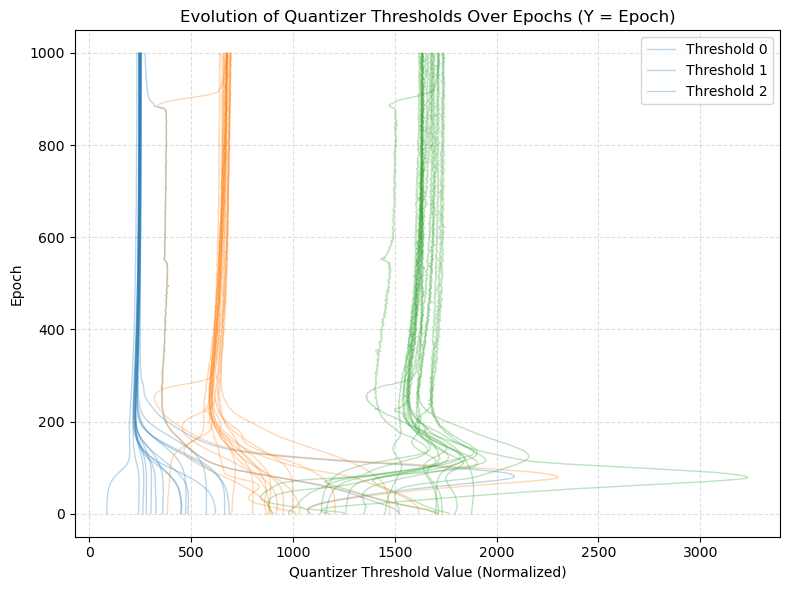

In [21]:
df_filtered = df_sorted[df_sorted["fingerprint"].isin(last_rows["fingerprint"])]

plt.figure(figsize=(8, 6))

for thr_col, color in zip(threshold_cols, colors):
    for fp in df_filtered["fingerprint"].unique():
        subset = df_filtered[df_filtered["fingerprint"] == fp]
        plt.plot(
            subset[thr_col],
            subset["epoch"],
            color=color,
            alpha=0.3,
            linewidth=1.0,
        )

plt.xlabel("Quantizer Threshold Value (Normalized)")
plt.ylabel("Epoch")
plt.title("Evolution of Quantizer Thresholds Over Epochs (Y = Epoch)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend([f"Threshold {i}" for i in range(len(threshold_cols))], loc="best")
plt.tight_layout()
plt.show()


In [22]:
df_filtered.keys()

Index(['epoch', 'loss', 'val_loss', 'fingerprint', 'best_val_metric',
       'quantizer_epoch', 'quantizer_k', 'quantizer_level_0',
       'quantizer_level_1', 'quantizer_level_2', 'quantizer_level_3',
       'quantizer_threshold_0', 'quantizer_threshold_1',
       'quantizer_threshold_2', 'first_modified'],
      dtype='object')

In [23]:
# --- Step 1: filter once, and keep this reference ---
df_filtered = df_sorted[df_sorted["fingerprint"].isin(last_rows["fingerprint"])].copy()
for i in range(3):
    df_sorted[f"charge_threshold_{i}"] = df_sorted[f"quantizer_threshold_{i}"]

df_filtered = df_sorted[df_sorted["fingerprint"].isin(last_rows["fingerprint"])].copy()
for i in range(3):
    df_sorted[f"charge_threshold_{i}"] = df_sorted[f"quantizer_threshold_{i}"]
    
# # --- Step 2: add charge thresholds to this same object ---
# for i in range(3):
#     df_filtered.loc[:, f"charge_threshold_{i}"] = df_filtered.apply(
#         lambda row: unnormalize_thresholds(
#             [row[f"quantizer_threshold_{i}"]],
#             mu=test_generator.dataset_mean[0],
#             sigma=test_generator.dataset_std[0],
#             s_pos=test_generator.norm_factor_pos,
#             s_neg=test_generator.norm_factor_neg,
#         )[0],
#         axis=1,
#     )

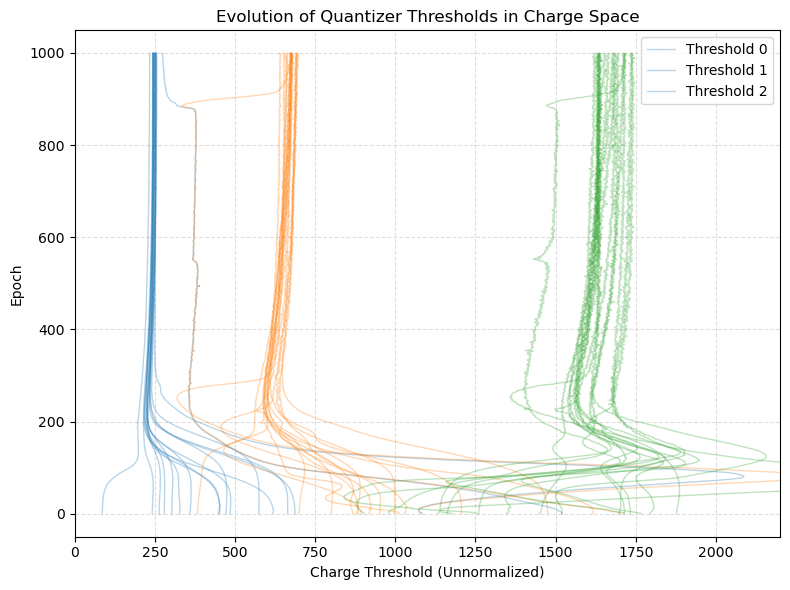

In [24]:
# --- Step 3: plot ---
threshold_cols = [f"charge_threshold_{i}" for i in range(3)]
colors = ["C0", "C1", "C2"]

plt.figure(figsize=(8, 6))
for thr_col, color in zip(threshold_cols, colors):
    for fp in df_filtered["fingerprint"].unique():
        subset = df_filtered[df_filtered["fingerprint"] == fp]
        plt.plot(
            subset[thr_col],
            subset["epoch"],
            color=color,
            alpha=0.3,
            linewidth=1.0,
        )

plt.xlabel("Charge Threshold (Unnormalized)")
plt.ylabel("Epoch")
plt.title("Evolution of Quantizer Thresholds in Charge Space")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend([f"Threshold {i}" for i in range(3)], loc="best")
plt.tight_layout()
plt.xlim([0, 2200])
plt.show()

In [25]:
plt.rcParams.update({
    "font.size": 14,           # base font size
    "axes.labelsize": 16,      # axis label font
    "axes.titlesize": 18,      # title font
    "xtick.labelsize": 13,     # x-tick labels
    "ytick.labelsize": 13,     # y-tick labels
    "legend.fontsize": 13,     # legend text
    "axes.linewidth": 1.5,     # axis thickness
    "lines.linewidth": 2.0,    # curve thickness
    "grid.alpha": 0.5,         # grid visibility
})

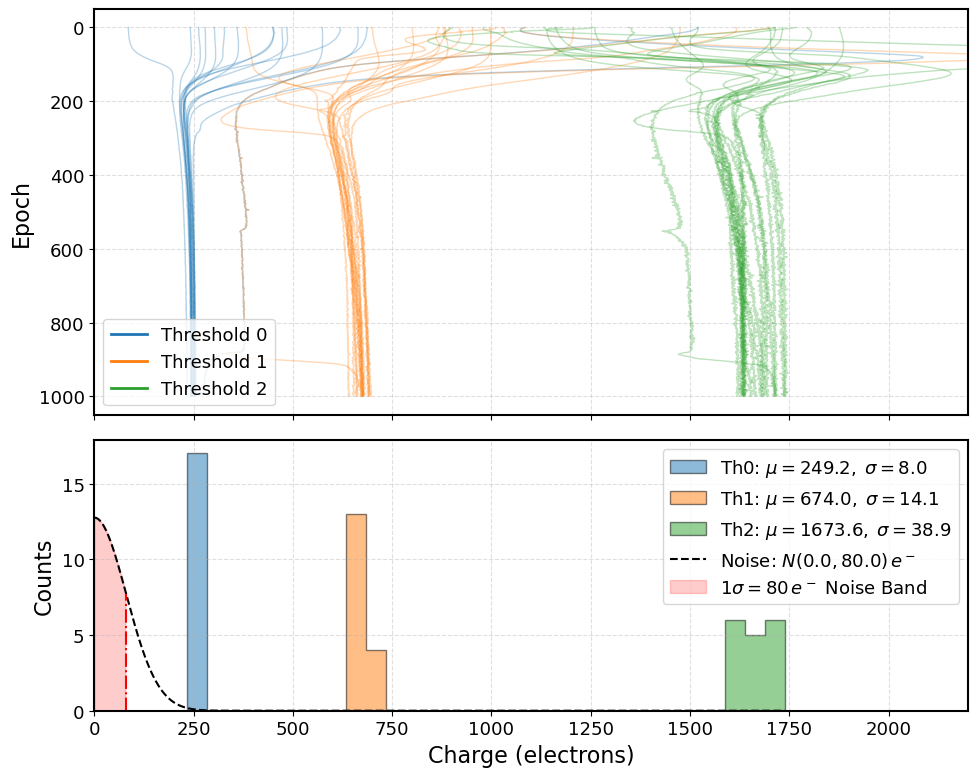

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

from scipy.stats import norm

# --- Assume df_filtered already has charge_threshold_0..2 computed ---
threshold_cols = [f"charge_threshold_{i}" for i in range(3)]
colors = ["C0", "C1", "C2"]  # blue/orange/green

# --- Collect final thresholds per run (last epoch only) ---
last_rows = (
    df_filtered.sort_values("epoch")
    .groupby("fingerprint", as_index=False)
    .tail(1)
)

raw_th0 = last_rows["charge_threshold_0"].to_numpy()
raw_th1 = last_rows["charge_threshold_1"].to_numpy()
raw_th2 = last_rows["charge_threshold_2"].to_numpy()

# --- Compute histogram bins ---
all_raw = np.concatenate([raw_th0, raw_th1, raw_th2])
bins = np.histogram_bin_edges(all_raw, bins=30)

# --- Layout with shared x-axis ---
fig, (ax_evol, ax_hist) = plt.subplots(
    2, 1, figsize=(10, 8), sharex=True,
    gridspec_kw={"height_ratios": [3, 2]}
)

i = 0
for thr_col, color in zip(threshold_cols, colors):
    for fp in df_filtered["fingerprint"].unique():
        subset = df_filtered[df_filtered["fingerprint"] == fp]
        ax_evol.plot(
            subset[thr_col],
            subset["epoch"],
            color=color,
            alpha=0.3,
            linewidth=1.0,
        )

ax_evol.set_ylabel("Epoch")
# ax_evol.set_title("Evolution of Charge Thresholds + Distribution Summary")
ax_evol.grid(True, linestyle="--", alpha=0.4)
ax_evol.invert_yaxis()

handles = [
    mlines.Line2D([], [], color='C0', lw=2, label='Threshold 0'),
    mlines.Line2D([], [], color='C1', lw=2, label='Threshold 1'),
    mlines.Line2D([], [], color='C2', lw=2, label='Threshold 2')
]

ax_evol.legend(handles=handles, loc="lower left", frameon=True)


mu0, sigma0 = np.mean(raw_th0), np.std(raw_th0)
mu1, sigma1 = np.mean(raw_th1), np.std(raw_th1)
mu2, sigma2 = np.mean(raw_th2), np.std(raw_th2)

label0 = rf"Th0: $\mu={mu0:.1f},\;\sigma={sigma0:.1f}$"
label1 = rf"Th1: $\mu={mu1:.1f},\;\sigma={sigma1:.1f}$"
label2 = rf"Th2: $\mu={mu2:.1f},\;\sigma={sigma2:.1f}$"

ax_hist.hist(raw_th0, bins=bins, alpha=0.5, color=colors[0],
              label=label0, histtype='stepfilled', edgecolor='black')
ax_hist.hist(raw_th1, bins=bins, alpha=0.5, color=colors[1],
              label=label1, histtype='stepfilled', edgecolor='black')
ax_hist.hist(raw_th2, bins=bins, alpha=0.5, color=colors[2],
              label=label2, histtype='stepfilled', edgecolor='black')

mu_noise = NOISE_MU
sigma_noise = NOISE_SIGMA
# --- Overlay noise PDF ---
x_pdf = np.linspace(0, max(bins), 1000)
pdf = norm.pdf(x_pdf, loc=mu_noise, scale=sigma_noise)
pdf_scaled = pdf * len(all_raw) * (bins[1] - bins[0])

ax_hist.plot(
    x_pdf, pdf_scaled,
    'k--', linewidth=1.5,
    label=rf"Noise: $N({mu_noise:.1f}, {sigma_noise:.1f})\,e^-$"
)

# --- Shaded 1σ region under noise PDF ---
in_band = (x_pdf >= mu_noise - sigma_noise) & (x_pdf <= mu_noise + sigma_noise)
ax_hist.fill_between(
    x_pdf, 0, pdf_scaled,
    where=in_band, color='red', alpha=0.2,
    label=rf"$1\sigma={sigma_noise:.0f}\,e^-$ Noise Band"
)

# --- Vertical lines marking ±1σ ---
pdf_val = norm.pdf(mu_noise + sigma_noise, loc=mu_noise, scale=sigma_noise)
pdf_val_scaled = pdf_val * len(all_raw) * (bins[1] - bins[0])
ax_hist.vlines(
    [mu_noise - sigma_noise, mu_noise + sigma_noise],
    0, pdf_val_scaled,
    color='red', linestyle='-.', linewidth=1.5
)

ax_hist.set_xlabel("Charge (electrons)")
ax_hist.set_ylabel("Counts")
ax_hist.grid(True, linestyle="--", alpha=0.4)
ax_hist.legend(loc="upper right")

plt.xlim([0, 2200])
plt.tight_layout()
plt.show()


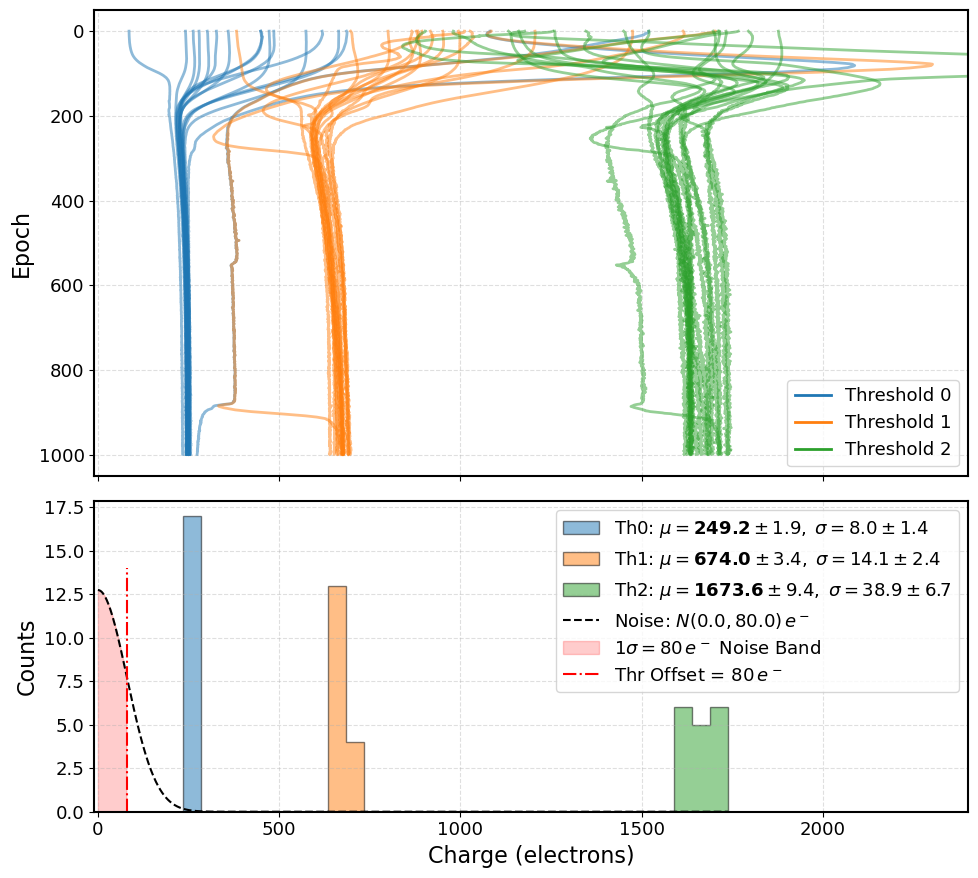

Th0: μ=249.17±1.94, σ =8.00±1.37
Th1: μ=673.97±3.43, σ =14.12±2.42
Th2: μ=1673.60±9.43, σ =38.88±6.67


In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.stats import norm
from iminuit import Minuit

def gaussian_nll(x, mu, sigma):
    if sigma <= 0:
        return np.inf
    return 0.5 * np.sum(np.log(2.0 * np.pi * sigma**2) + ((x - mu) / sigma) ** 2)

def fit_gaussian_thresholds(values, label="Th"):
    x = np.asarray(values, dtype=np.float64)
    mu0, sigma0 = x.mean(), x.std(ddof=0)
    m = Minuit(lambda mu, sigma: gaussian_nll(x, mu, sigma), mu=mu0, sigma=sigma0)
    m.errordef = Minuit.LIKELIHOOD      # correct for NLL
    m.limits["sigma"] = (1e-12, None)   # keep σ > 0
    m.migrad(); m.hesse()
    mu, sigma = m.values["mu"], m.values["sigma"]
    dmu, dsigma = m.errors["mu"], m.errors["sigma"]
    return mu, sigma, dmu, dsigma
# ───────────────────────────────────────────────────────────────────

threshold_cols = [f"charge_threshold_{i}" for i in range(3)]
colors = ["C0", "C1", "C2"]  # blue/orange/green

last_rows = (
    df_filtered.sort_values("epoch")
    .groupby("fingerprint", as_index=False)
    .tail(1)
)

raw_th0 = last_rows["charge_threshold_0"].to_numpy()
raw_th1 = last_rows["charge_threshold_1"].to_numpy()
raw_th2 = last_rows["charge_threshold_2"].to_numpy()

all_raw = np.concatenate([raw_th0, raw_th1, raw_th2])
bins = np.histogram_bin_edges(all_raw, bins=30)

fig, (ax_evol, ax_hist) = plt.subplots(
    2, 1, figsize=(10, 9), sharex=True,
    gridspec_kw={"height_ratios": [3, 2]}
)


for thr_col, color in zip(threshold_cols, colors):
    for fp in df_filtered["fingerprint"].unique():
        subset = df_filtered[df_filtered["fingerprint"] == fp]
        ax_evol.plot(
            subset[thr_col],
            subset["epoch"],
            color=color,
            alpha=0.5,
            linewidth=2.0,
        )

ax_evol.set_ylabel("Epoch")
ax_evol.grid(True, linestyle="--", alpha=0.4)
ax_evol.invert_yaxis()

handles = [
    mlines.Line2D([], [], color='C0', lw=2, label='Threshold 0'),
    mlines.Line2D([], [], color='C1', lw=2, label='Threshold 1'),
    mlines.Line2D([], [], color='C2', lw=2, label='Threshold 2')
]
ax_evol.legend(handles=handles, loc="lower right", frameon=True)

mu0, sigma0, dmu0, dsigma0 = fit_gaussian_thresholds(raw_th0, "Th0")
mu1, sigma1, dmu1, dsigma1 = fit_gaussian_thresholds(raw_th1, "Th1")
mu2, sigma2, dmu2, dsigma2 = fit_gaussian_thresholds(raw_th2, "Th2")

label0 = rf"Th0: $\mu=\mathbf{{{mu0:.1f}}}\pm{dmu0:.1f},\;\sigma={sigma0:.1f}\pm{dsigma0:.1f}$"
label1 = rf"Th1: $\mu=\mathbf{{{mu1:.1f}}}\pm{dmu1:.1f},\;\sigma={sigma1:.1f}\pm{dsigma1:.1f}$"
label2 = rf"Th2: $\mu=\mathbf{{{mu2:.1f}}}\pm{dmu2:.1f},\;\sigma={sigma2:.1f}\pm{dsigma2:.1f}$"

ax_hist.hist(raw_th0, bins=bins, alpha=0.5, color=colors[0],
              label=label0, histtype='stepfilled', edgecolor='black')
ax_hist.hist(raw_th1, bins=bins, alpha=0.5, color=colors[1],
              label=label1, histtype='stepfilled', edgecolor='black')
ax_hist.hist(raw_th2, bins=bins, alpha=0.5, color=colors[2],
              label=label2, histtype='stepfilled', edgecolor='black')

# --- Overlay noise PDF ---
x_pdf = np.linspace(0, max(bins), 1000)
pdf = norm.pdf(x_pdf, loc=mu_noise, scale=sigma_noise)
pdf_scaled = pdf * len(all_raw) * (bins[1] - bins[0])

ax_hist.plot(
    x_pdf, pdf_scaled,
    'k--', linewidth=1.5,
    label=rf"Noise: $N({mu_noise:.1f}, {sigma_noise:.1f})\,e^-$"
)

# --- Shaded 1σ region under noise PDF ---
in_band = (x_pdf >= mu_noise - sigma_noise) & (x_pdf <= mu_noise + sigma_noise)
ax_hist.fill_between(
    x_pdf, 0, pdf_scaled,
    where=in_band, color='red', alpha=0.2,
    label=rf"$1\sigma={sigma_noise:.0f}\,e^-$ Noise Band"
)

# --- Vertical lines marking ±1σ ---
pdf_val = norm.pdf(mu_noise + sigma_noise, loc=mu_noise, scale=sigma_noise)
pdf_val_scaled = pdf_val * len(all_raw) * (bins[1] - bins[0])
# ax_hist.vlines(
#     0,
#     # [mu_noise - sigma_noise, mu_noise + sigma_noise],
#     0, pdf_val_scaled,
#     color='red', linestyle='-.', linewidth=1.5, label = r"Thr Offset = $0 e^-$"
# )

ax_hist.vlines(
    x=80,
    ymin=0,
    ymax=14,
    color='red',
    linestyle='-.',
    linewidth=1.5,
    label=r"Thr Offset = $80\,e^-$"
)

ax_hist.set_xlabel("Charge (electrons)")
ax_hist.set_ylabel("Counts")
ax_hist.grid(True, linestyle="--", alpha=0.4)
ax_hist.legend(loc="upper right")
# ax_hist.set_ylim(0, 45)

plt.xlim([-10, 2400])
plt.tight_layout()
plt.savefig(
    "Thr_summary.png",   # or .svg / .pdf for vector
    dpi=300,                    # high resolution
    # bbox_inches='tight',       # remove excess whitespace
)
plt.show()


print(rf"Th0: μ={mu0:.2f}±{dmu0:.2f}, σ ={sigma0:.2f}±{dsigma0:.2f}")
print(rf"Th1: μ={mu1:.2f}±{dmu1:.2f}, σ ={sigma1:.2f}±{dsigma1:.2f}")
print(rf"Th2: μ={mu2:.2f}±{dmu2:.2f}, σ ={sigma2:.2f}±{dsigma2:.2f}")

In [28]:
from ipywidgets import IntSlider, Play, jslink, HBox, VBox, Layout, Output
from IPython.display import display, clear_output

# Define the columns and colors we'll use
threshold_cols = [f"charge_threshold_{i}" for i in range(3)]
colors = ["C0", "C1", "C2"]  # blue/orange/green

# Get a list of all unique fingerprints
all_fingerprints = df_filtered["fingerprint"].unique()

if df_filtered.empty:
    max_epoch = 0
else:
    max_epoch = df_filtered["epoch"].max()

sl_epoch = IntSlider(
    value=0, min=0, max=max_epoch,
    description="Epoch:",
    layout=Layout(width="500px"),
    continuous_update=True
)

play = Play(interval=100, value=0, min=0, max=sl_epoch.max, step=1)
jslink((play, "value"), (sl_epoch, "value")) # Link play button to slider

controls = HBox([play, sl_epoch], layout=Layout(align_items="center", gap="10px"))

# Create an Output widget to hold the plot
plot_output = Output(layout=Layout(border="1px solid #ddd"))


# --- 2. Define the Plotting Function ---
# This function will draw *all* fingerprints up to the selected epoch
def draw_plot(selected_epoch):
    
    # Filter the *entire* dataframe to only include history up to the epoch
    df_history = df_filtered[df_filtered["epoch"] <= selected_epoch]

    # We draw inside the 'plot_output' widget
    with plot_output:
        clear_output(wait=True) # Clear the previous plot
        
        fig, ax = plt.subplots(1, 1, figsize=(10, 7))
        for thr_col, color in zip(threshold_cols, colors):
            for fp in all_fingerprints:
                # Get the *history* data for this one fingerprint
                subset = df_history[df_history["fingerprint"] == fp].sort_values("epoch")
                
                if subset.empty:
                    continue
                ax.plot(
                    subset[thr_col],     # X-axis
                    subset["epoch"],     # Y-axis
                    color=color,         # Use C0, C1, or C2
                    alpha=0.3,           # Faint alpha to see all lines
                    linewidth=1.0,       # Thin lines
                )

        ax.set_xlabel("Charge (electrons)")
        ax.set_ylabel("Epoch")
        ax.grid(True, linestyle="--", alpha=0.4)

        ax.invert_yaxis()
        ax.set_ylim(1000, 0)
        ax.axhline(selected_epoch, ls="--", color="k", lw=1.0, alpha=0.6)
        handles = [
            mlines.Line2D([], [], color='C0', lw=2, label='Threshold 0'),
            mlines.Line2D([], [], color='C1', lw=2, label='Threshold 1'),
            mlines.Line2D([], [], color='C2', lw=2, label='Threshold 2')
        ]
        ax.legend(handles=handles, loc="lower right", frameon=True)

        try:
            all_vals = df_filtered[threshold_cols].to_numpy()
            xmin = np.nanmin(all_vals)
            xmax = np.nanmax(all_vals)
            pad = (xmax - xmin) * 0.05 if (xmax - xmin) > 0 else 1
            ax.set_xlim(xmin - pad, xmax + pad)
        except Exception:
            pass # Ignore errors if data is empty/all-NaN

        plt.tight_layout()
        plt.show()

def on_slider_change(change):
    """When the slider changes, redraw the plot."""
    if change['name'] == 'value':
        draw_plot(selected_epoch=change['new'])

sl_epoch.observe(on_slider_change, names='value')
display(VBox([controls, plot_output]))
draw_plot(selected_epoch=sl_epoch.value)

In [29]:
import math
import matplotlib.lines as mlines
from matplotlib.animation import FuncAnimation, PillowWriter, FFMpegWriter
from tqdm.auto import tqdm

def save_epoch_animation(
    df_filtered,
    threshold_cols=("charge_threshold_0", "charge_threshold_1", "charge_threshold_2"),
    colors=("C0", "C1", "C2"),
    out_path="charge_thresholds.gif",   # use ".mp4" for faster finalization
    fps=8,
    dpi=150,
    frame_step=1,
    epochs_per_second=None              # NEW: desired playback speed in epochs/sec
):
    if df_filtered is None or df_filtered.empty:
        raise ValueError("df_filtered is empty; nothing to animate.")
    for col in ["epoch", "fingerprint", *threshold_cols]:
        if col not in df_filtered.columns:
            raise ValueError(f"Required column missing: {col}")

    all_fps = df_filtered["fingerprint"].unique()
    max_epoch = int(df_filtered["epoch"].max())

    # --- derive fps & frame_step from epochs_per_second if requested ---
    if epochs_per_second is not None:
        # Keep fps in a broadly compatible range for GIFs (<=30); push speed via frame_step.
        target_fps = max(1, min(30, int(round(min(epochs_per_second, 30)))))
        step = max(1, int(math.ceil(epochs_per_second / target_fps)))
        # Recompute fps so that fps*step ~= epochs_per_second (integer fps)
        fps = max(1, min(50, int(round(epochs_per_second / step))))
        frame_step = step

    # x-limits from data
    all_vals = df_filtered[list(threshold_cols)].to_numpy(dtype=float)
    xmin = np.nanmin(all_vals); xmax = np.nanmax(all_vals)
    pad = (xmax - xmin) * 0.05 if (xmax - xmin) > 0 else 1.0
    # xlim = (xmin - pad, xmax + pad)
    xlim = (-10, 2400)

    # Build artists
    lines_meta = []
    fig, ax = plt.subplots(1, 1, figsize=(10, 7), dpi=dpi)
    for thr_col, color in zip(threshold_cols, colors):
        for fp in all_fps:
            subset = (
                df_filtered.loc[df_filtered["fingerprint"] == fp, ["epoch", thr_col]]
                .dropna()
                .sort_values("epoch")
            )
            if subset.empty:
                continue
            y_all = subset["epoch"].to_numpy(dtype=float)
            x_all = subset[thr_col].to_numpy(dtype=float)
            ln, = ax.plot([], [], color=color, alpha=0.5, linewidth=2.0)
            lines_meta.append({"line": ln, "y_all": y_all, "x_all": x_all})

    ax.set_xlabel("Charge (electrons)")
    ax.set_ylabel("Epoch")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_xlim(*xlim)

    # Proper inversion: ascending limits then invert
    ax.set_ylim(0, max_epoch)
    ax.invert_yaxis()

    frames = list(range(0, max_epoch + 1, max(1, int(frame_step))))
    now_line = ax.axhline(frames[0], ls="--", color="k", lw=1.0, alpha=0.6)

    handles = [
        mlines.Line2D([], [], color='C0', lw=2, label='Threshold 0'),
        mlines.Line2D([], [], color='C1', lw=2, label='Threshold 1'),
        mlines.Line2D([], [], color='C2', lw=2, label='Threshold 2'),
    ]
    ax.legend(handles=handles, loc="lower right", frameon=True)
    fig.tight_layout()

    def update(epoch):
        now_line.set_ydata([epoch, epoch])
        for meta in lines_meta:
            mask = meta["y_all"] <= epoch
            meta["line"].set_data(meta["x_all"][mask], meta["y_all"][mask])
        return [now_line] + [m["line"] for m in lines_meta]

    anim = FuncAnimation(fig, update, frames=frames, interval=1000 / fps, blit=False, repeat=False)

    # Writer
    ext = out_path.split(".")[-1].lower()
    if ext == "gif":
        writer = PillowWriter(fps=fps)
    elif ext in ("mp4", "m4v"):
        writer = FFMpegWriter(fps=fps, codec="libx264", bitrate=1800)
    else:
        plt.close(fig)
        raise ValueError("out_path must end with .gif or .mp4")

    # Progress
    pbar = tqdm(total=len(frames), desc="Rendering frames", unit="frame")
    def _progress(i, n):
        pbar.total = n
        pbar.n = i + 1
        pbar.refresh()

    anim.save(out_path, writer=writer, dpi=dpi, progress_callback=_progress)
    pbar.close()
    plt.close(fig)

    eff_eps = fps * (frames[1] - frames[0]) if len(frames) > 1 else 0
    print(f"Saved {out_path} ({len(frames)} frames @ {fps} fps, frame_step={frame_step}, ~{eff_eps:.1f} epochs/s)")


In [34]:
save_epoch_animation(df_filtered, threshold_cols, colors, dpi=150,
                     out_path="faster.gif", epochs_per_second=400)


Rendering frames:   0%|          | 0/73 [00:00<?, ?frame/s]

In [35]:
df_filtered['fingerprint'].unique()

array(['06e9d69b', '1b3eb4c0', '331f69d9', '3e6d132d', '5512f272',
       '6d008cb4', '747dd304', '843ca551', '848c0897', '88348cd5',
       '8b902f5c', 'a603a1e4', 'b86c56aa', 'bf9385c2', 'd2560da0',
       'df3576e1', 'f7093404'], dtype=object)

In [36]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.animation import FuncAnimation, PillowWriter, FFMpegWriter
from tqdm.auto import tqdm

def save_epoch_animation(
    df_filtered,
    threshold_cols=("charge_threshold_0","charge_threshold_1","charge_threshold_2"),
    colors=("C0","C1","C2"),
    out_path="charge_thresholds.gif",
    fps=8,
    dpi=150,
    frame_step=1,
    epochs_per_second=None,
    debug_first_frame_png=None  # e.g. "debug_frame0.png"
):
    if df_filtered is None or df_filtered.empty:
        raise ValueError("df_filtered is empty; nothing to animate.")
    for col in ["epoch","fingerprint",*threshold_cols]:
        if col not in df_filtered.columns:
            raise ValueError(f"Required column missing: {col}")

    all_fps = df_filtered["fingerprint"].unique()
    max_epoch = int(df_filtered["epoch"].max())

    if epochs_per_second is not None:
        target_fps = max(1, min(30, int(round(min(epochs_per_second, 30)))))
        step = max(1, int(math.ceil(epochs_per_second / target_fps)))
        fps = max(1, min(50, int(round(epochs_per_second / step))))
        frame_step = step

    # X-limits (robust to all-NaN)
    vals = df_filtered[list(threshold_cols)].to_numpy(dtype=float)
    finite_vals = vals[np.isfinite(vals)]
    if finite_vals.size >= 2:
        xmin = float(np.nanmin(finite_vals)); xmax = float(np.nanmax(finite_vals))
        pad = (xmax - xmin) * 0.05 if (xmax - xmin) > 0 else 1.0
        xlim = (xmin - pad, xmax + pad)
    elif finite_vals.size == 1:
        x0 = float(finite_vals[0]); xlim = (x0 - 1.0, x0 + 1.0)
    else:
        xlim = (-1.0, 1.0)

    fig, ax = plt.subplots(1, 1, figsize=(10, 7), dpi=dpi)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # Build lines
    lines_meta = []
    for thr_col, color in zip(threshold_cols, colors):
        for fp in all_fps:
            subset = (
                df_filtered.loc[df_filtered["fingerprint"] == fp, ["epoch", thr_col]]
                .dropna()
                .sort_values("epoch")
            )
            if subset.empty:
                continue
            y_all = subset["epoch"].to_numpy(dtype=float)
            x_all = subset[thr_col].to_numpy(dtype=float)
            ln, = ax.plot([], [], color=color, alpha=0.9, linewidth=2.5)
            lines_meta.append({"line": ln, "y_all": y_all, "x_all": x_all})
    if not lines_meta:
        raise ValueError("No drawable data after filtering (all thresholds NaN for this slice).")

    ax.set_xlabel("Charge (electrons)")
    ax.set_ylabel("Epoch")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_xlim(*xlim)

    # Pad y-range, then invert
    ymin, ymax = 0, max_epoch
    if ymax <= ymin:  # pathological case
        ymax = ymin + 1
    ax.set_ylim(ymin - 0.5, ymax + 0.5)
    ax.invert_yaxis()

    # Frames
    step = max(1, int(frame_step))
    frames = list(range(0, max_epoch + 1, step))
    if frames[-1] != max_epoch:
        frames.append(max_epoch)

    # Explicit epoch line spanning x-limits
    now_line, = ax.plot([xlim[0], xlim[1]], [frames[0], frames[0]], ls="--", color="k", lw=1.6, alpha=0.85)

    handles = [
        mlines.Line2D([], [], color='C0', lw=2.5, label='Threshold 0'),
        mlines.Line2D([], [], color='C1', lw=2.5, label='Threshold 1'),
        mlines.Line2D([], [], color='C2', lw=2.5, label='Threshold 2'),
    ]
    ax.legend(handles=handles, loc="lower right", frameon=True)
    fig.tight_layout()

    def update(epoch):
        now_line.set_data([xlim[0], xlim[1]], [epoch, epoch])
        for meta in lines_meta:
            mask = meta["y_all"] <= epoch
            meta["line"].set_data(meta["x_all"][mask], meta["y_all"][mask])
        return [now_line] + [m["line"] for m in lines_meta]

    # Optional sanity snapshot before animating
    if debug_first_frame_png:
        update(frames[0])
        fig.savefig(debug_first_frame_png, facecolor="white", edgecolor="none", dpi=dpi)

    anim = FuncAnimation(fig, update, frames=frames, interval=1000 / fps, blit=False, repeat=False)

    ext = out_path.split(".")[-1].lower()
    if ext == "gif":
        writer = PillowWriter(fps=fps)
    elif ext in ("mp4", "m4v"):
        writer = FFMpegWriter(fps=fps, codec="libx264", bitrate=1800)
    else:
        plt.close(fig)
        raise ValueError("out_path must end with .gif or .mp4")

    pbar = tqdm(total=len(frames), desc="Rendering frames", unit="frame")
    def _progress(i, n):
        pbar.total = n
        pbar.n = i + 1
        pbar.refresh()

    anim.save(
        out_path,
        writer=writer,
        dpi=dpi,
        progress_callback=_progress,
        savefig_kwargs={"facecolor": "white", "edgecolor": "none"}
    )
    pbar.close()
    plt.close(fig)


In [37]:
target_fingerprint = '5512f272'
df_filtered_sfp = df_filtered[df_filtered['fingerprint'] == target_fingerprint]

print(df_filtered_sfp.empty)
print(df_filtered_sfp['epoch'].agg(['min','max','nunique']))
print(df_filtered_sfp[threshold_cols].apply(lambda s: (~s.isna()).sum()))


save_epoch_animation(df_filtered_sfp, threshold_cols, colors, dpi=150,
                     out_path="sfp_faster.gif", epochs_per_second=400)

False
min           0
max         999
nunique    1000
Name: epoch, dtype: int64
charge_threshold_0    1000
charge_threshold_1    1000
charge_threshold_2    1000
dtype: int64


Rendering frames:   0%|          | 0/73 [00:00<?, ?frame/s]